<a href="https://colab.research.google.com/github/alvarezaguayomiguel1472-commits/Aprendizaje-Automatico/blob/main/Naive_Bayes_y_m%C3%A9tricas_de_evaluaci%C3%B3n_Miguel_Alvarez_Aguayo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparativa (Gaussiano, Multinomial y Bernoulli)
## Descripción:
- Dataset: load_breast_cancer, fetch_20newsgroups de sklearn
- Objetivo: Clasificar los tumores como benignos o malignos.

## Autor: Álvarez Aguayo Miguel Alejandro
## Fecha: 16/06/2026

In [ ]:
# Naive Bayes Gaussiano
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
import seaborn as sns
import matplotlib.pyplot as plt


datos = load_breast_cancer()


X = datos.data
y = datos.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 24)

modelo = GaussianNB()

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)





In [ ]:
# Naive Bayes Multinomial
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB



categorias = [
    'sci.space',
    'rec.sport.baseball'
]

datos = fetch_20newsgroups(subset = 'train', categories=categorias)

vectorizador = CountVectorizer()

Xm = vectorizador.fit_transform(datos.data)

ym = datos.target

X_trainM, X_testM, y_trainM, y_testM = train_test_split(Xm, ym, test_size = 0.3, random_state=24)

modeloM = MultinomialNB()

modeloM.fit(X_trainM, y_trainM)

y_predM = modeloM.predict(X_testM)


In [ ]:
# Bernoulli Naive Bayes
from sklearn.naive_bayes import BernoulliNB
modeloB = BernoulliNB()
modeloB.fit(X_trainM, y_trainM)
y_predB = modeloB.predict(X_testM)


============= Comparación de Clasificadores =============
Métrica         Gaussiano       Multinomial     Bernoulli 
-----------------------------------------------------------------
Accuracy        0.9211          0.9972          0.9160
Precision       0.9444          1.0000          1.0000
Recall          0.9315          0.9941          0.9930
F1-Score        0.9379          0.9971          0.9930



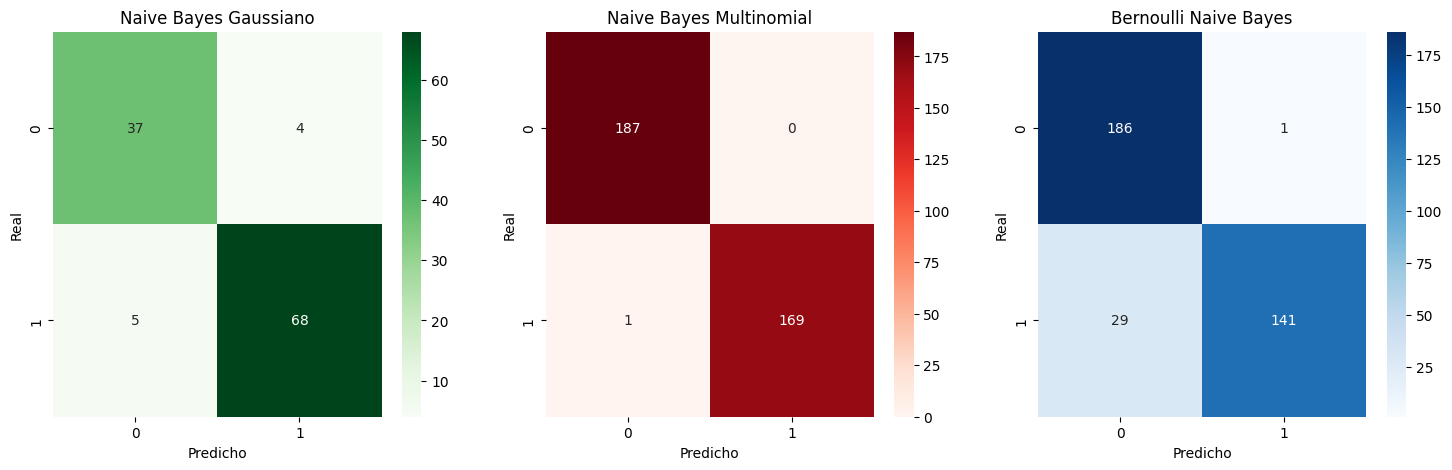

In [ ]:

print("============= Comparación de Clasificadores =============")
print(f"{'Métrica':<15} {'Gaussiano':<15} {'Multinomial':<15} {'Bernoulli':<10}")
print("-" * 65)

#Accuracy
accuracy_gaussiano = accuracy_score(y_test, y_pred)
accuracy_multinomial = accuracy_score(y_testM, y_predM)
accuracy_bernoulli = accuracy_score(y_testM, y_predB)
print(f"{'Accuracy':<15} {accuracy_gaussiano:<15.4f} {accuracy_multinomial:<15.4f} {accuracy_bernoulli:.4f}")


#Precision
precision_gaussiano = precision_score(y_test, y_pred)
precision_multinomial = precision_score(y_testM, y_predM)
precision_bernoulli = precision_score(y_testM, y_predB)
print(f"{'Precision':<15} {precision_gaussiano:<15.4f} {precision_multinomial:<15.4f} {precision_multinomial:.4f}")


# Recall
recall_gaussiano = recall_score(y_test, y_pred)
recall_multinomial = recall_score(y_testM, y_predM)
recall_bernoulli = precision_score(y_testM, y_predB)
print(f"{'Recall':<15} {recall_gaussiano:<15.4f} {recall_multinomial:<15.4f} {recall_bernoulli:.4f}")


# F1
f1_gaussiano = f1_score(y_test, y_pred)
f1_multinomial= f1_score(y_testM, y_predM)
f1_bernoulli = precision_score(y_testM, y_predB)
print(f"{'F1-Score':<15} {f1_gaussiano:<15.4f} {f1_multinomial:<15.4f} {f1_bernoulli:.4f}\n")


# Graficos de Matrices de confusión

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matriz_confusion_g = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz_confusion_g, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Naive Bayes Gaussiano')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

matriz_confusion_m = confusion_matrix(y_testM, y_predM)
sns.heatmap(matriz_confusion_m, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('Naive Bayes Multinomial')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

matriz_confusion_b = confusion_matrix(y_testM, y_predB)
sns.heatmap(matriz_confusion_b, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Bernoulli Naive Bayes')
axes[2].set_xlabel('Predicho')
axes[2].set_ylabel('Real')

plt.show()

# Antes de pasar a la conclusion, debemos evidenciar que se uso un dataset distinto para implementar Naive Bayes Gaussiano, por lo tanto, si comparamos entre los clasificadores Naive Bayes Multinomial y Bernoulli Naive Bayes podemos ver que el modelo Multinomial tuvo un mejor rendimiento en casi todas las métricas que se evaluaron.